In [52]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier


In [53]:
# ------------------------
# Configuration
# ------------------------
seeds = [0, 2, 4, 10, 20]
init_samples = 30            # start with exactly 30 labeled samples
step = 10                     # samples to query per iteration (set to 10 for batch of 10)
max_frac = 0.5               # stop if reach 50% of training data
cv_folds = 5
n_mc_passes = 20

# Shared stopping: plateau on CV accuracy
shared_stop = {
    'm_rounds': 5,      # number of rounds to check
    'acc_delta': 0.002  # max allowed change in accuracy
}


In [54]:
# Per-model stopping params
stop_params = {
    'Random Forest': {'eps': 0.1, 'm': 5},
    'SGD': {
        'eps': 0.1,         # least confidence threshold
        'm_least': 5,       # rounds for least confidence collapse
        'delta_stab': 0.002,# stability delta threshold
        'm_stab': 5,        # rounds for stability
        'ent_thresh': 0.05  # no info gain threshold
    },
    'MLP MC Dropout': {'eps': 0.05, 'm': 5},
    'MLP Least Confidence': {'eps': 0.05, 'm': 5},
    'MLP Random': {}     # no model-specific, rely on shared only
}

In [55]:
# ------------------------
# Load & preprocess
# ------------------------
print("Loading data...")
df = pd.read_csv("vc_mutant_data.csv", header=None)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# hold-out test set
X_train_full, X_test, y_train_full, y_test = \
    train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


Loading data...


In [56]:
# ------------------------
# Model definitions
# ------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.out = nn.Linear(128, out_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

class MLPDropout(nn.Module):
    def __init__(self, in_dim, out_dim, dropout_rate=0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.do = nn.Dropout(dropout_rate)
        self.out = nn.Linear(128, out_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.do(x)
        x = F.relu(self.fc2(x))
        x = self.do(x)
        return self.out(x)


In [57]:
# ------------------------
# Utility functions
# ------------------------
def train_epoch(model, loader, crit, opt, device):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()

def evaluate(model, Xv, yv, device):
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(Xv).to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy()
    return accuracy_score(yv, preds)

def cross_val_pytorch(Xd, yd, in_dim, out_dim, device, epochs=30):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    accs = []
    for tr, va in skf.split(Xd, yd):
        m = MLP(in_dim, out_dim).to(device)
        crit = nn.CrossEntropyLoss()
        opt = torch.optim.Adam(m.parameters(), lr=1e-3)
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.FloatTensor(Xd[tr]), torch.LongTensor(yd[tr])
            ), batch_size=64, shuffle=True)
        for _ in range(epochs): train_epoch(m, loader, crit, opt, device)
        accs.append(evaluate(m, Xd[va], yd[va], device))
    return np.mean(accs)

def cross_val_sklearn(clf, Xd, yd):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    accs = []
    for tr, va in skf.split(Xd, yd):
        clf.fit(Xd[tr], yd[tr])
        accs.append(accuracy_score(yd[va], clf.predict(Xd[va])))
    return np.mean(accs)

def predict_mc_dropout(model, Xd, device, n_passes):
    model.train()
    Xd = torch.FloatTensor(Xd).to(device)
    all_probs = []
    with torch.no_grad():
        for _ in range(n_passes):
            logits = model(Xd)
            all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.mean(np.stack(all_probs), axis=0)

def entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-12), axis=1)

In [58]:
# ------------------------
# Active Learning Loop
# ------------------------
def run_active_learning(strategy, use_mc=False, use_rf=False, use_sgd=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_histories = {}

    for seed in seeds:
        np.random.seed(seed); torch.manual_seed(seed)
        # shuffle data
        Xs, ys = shuffle(X_train_full, y_train_full, random_state=seed)
        n_total = len(Xs)
        n_max = int(max_frac * n_total)
        # init pools
        labeled   = np.random.choice(n_total, init_samples, replace=False)
        unlabeled = np.setdiff1d(np.arange(n_total), labeled)

        history = { 'n_labeled':[], 'cv_acc':[], 'test_acc':[],
                    'batch_uncert':[], 'pool_entropy':[], 'batch_entropy':[] }
        recent_acc = []
        batch_uncs = []

        title = ("Random Forest" if use_rf else
                 "SGD" if use_sgd else
                 "MLP MC Dropout" if use_mc else
                 "MLP Least Confidence" if strategy=="least_conf" else
                 "MLP Random")
        params = stop_params[title]
        sp = shared_stop

        while True:
            # train & eval
            if use_rf or use_sgd:
                clf = (RandomForestClassifier(n_estimators=200, max_depth=20,
                                               class_weight='balanced', random_state=seed)
                       if use_rf else
                       SGDClassifier(loss='log_loss', alpha=1e-4,
                                     max_iter=1000, tol=1e-3, random_state=seed))
                cv_score = cross_val_sklearn(clf, Xs[labeled], ys[labeled])
                clf.fit(Xs[labeled], ys[labeled])
                test_score = accuracy_score(y_test, clf.predict(X_test))
            else:
                cv_score = cross_val_pytorch(Xs[labeled], ys[labeled], X.shape[1], len(np.unique(y)), device)
                Model = MLPDropout if use_mc else MLP
                model = Model(X.shape[1], len(np.unique(y))).to(device)
                loader = torch.utils.data.DataLoader(
                    torch.utils.data.TensorDataset(
                        torch.FloatTensor(Xs[labeled]), torch.LongTensor(ys[labeled])
                    ), batch_size=64, shuffle=True)
                crit = nn.CrossEntropyLoss()
                opt  = torch.optim.Adam(model.parameters(), lr=1e-3)
                for _ in range(30): train_epoch(model, loader, crit, opt, device)
                test_score = evaluate(model, X_test, y_test, device)

            # log
            history['n_labeled'].append(len(labeled))
            history['cv_acc'].append(cv_score)
            history['test_acc'].append(test_score)
            recent_acc.append(cv_score)

            # shared stopping
            if len(recent_acc) > sp['m_rounds']:
                deltas = np.abs(np.diff(recent_acc[-sp['m_rounds']:]))
                if np.max(deltas) < sp['acc_delta']:
                    print(f"{title}: stopping (CV plateau)")
                    break

            # budget cap
            if len(labeled) >= n_max:
                print(f"{title}: reached budget cap")
                break

            # get pool probs
            if use_rf or use_sgd:
                probs_pool = clf.predict_proba(Xs[unlabeled])
            else:
                model.eval()
                with torch.no_grad():
                    logits = model(torch.FloatTensor(Xs[unlabeled]).to(device))
                    probs_pool = torch.softmax(logits, dim=1).cpu().numpy()

            pu_ent = entropy(probs_pool).mean()
            history['pool_entropy'].append(pu_ent)

            # uncertainties per sample
            uncs = 1 - np.max(probs_pool, axis=1)
            batch_unc = None
            batch_entropy = None
            if strategy == 'random':
                pick = np.random.choice(len(unlabeled), step, replace=False)
            else:
                if use_mc and strategy=='mc_dropout':
                    mc_probs = predict_mc_dropout(model, Xs[unlabeled], device, n_mc_passes)
                    uncs = entropy(mc_probs)
                order = np.argsort(uncs)
                pick = order[-step:]

            batch_unc = uncs[pick].mean()
            history['batch_uncert'].append(batch_unc)
            # batch entropy
            batch_entropy = entropy(probs_pool[pick]).mean()
            history['batch_entropy'].append(batch_entropy)
            batch_uncs.append(batch_unc)

            # model-specific stopping
            if title == 'Random Forest':
                p = params
                if len(batch_uncs) >= p['m'] and all(u < p['eps'] for u in batch_uncs[-p['m']:]):
                    print(f"{title}: stopping (uncertainty collapse)")
                    break
            elif title == 'SGD':
                p = params
                # least confidence
                if len(batch_uncs) >= p['m_least'] and all(u < p['eps'] for u in batch_uncs[-p['m_least']:]):
                    print(f"{title}: stopping (least conf)")
                    break
                # stability
                if len(batch_uncs) >= p['m_stab']:
                    deltas = np.abs(np.diff(batch_uncs[-p['m_stab']:]))
                    if np.max(deltas) < p['delta_stab']:
                        print(f"{title}: stopping (stability)")
                        break
                # no info gain
                if abs(pu_ent - batch_entropy) < p['ent_thresh']:
                    print(f"{title}: stopping (no info gain)")
                    break
            elif title == 'MLP MC Dropout':
                p = params
                if len(batch_uncs) >= p['m'] and all(batch_entropy < p['eps'] for batch_entropy in history['batch_entropy'][-p['m']:]):
                    print(f"{title}: stopping (entropy collapse)")
                    break
            elif title.startswith('MLP') and 'Least Confidence' in title:
                p = params
                if len(batch_uncs) >= p['m'] and all(u < p['eps'] for u in batch_uncs[-p['m']:]):
                    print(f"{title}: stopping (least conf)")
                    break

            # update pools
            to_label = unlabeled[pick]
            labeled = np.concatenate([labeled, to_label])
            unlabeled = np.setdiff1d(unlabeled, to_label)

        all_histories[title + f"_seed{seed}"] = history

    return all_histories

In [59]:
# ------------------------
# Plotting
# ------------------------
def plot_active_learning(histories):
    plt.figure(figsize=(10, 6))
    for name, hist in histories.items():
        plt.plot(hist['n_labeled'], hist['cv_acc'], label=name)
        # mark stopping
        plt.scatter(hist['n_labeled'][-1], hist['cv_acc'][-1], marker='x')
    plt.xlabel('Number of labeled samples')
    plt.ylabel('CV Accuracy')
    plt.title('Active Learning Curves with Stopping')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


MLP Random: reached budget cap


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 4 members, which is less than n_sp

MLP Random: reached budget cap


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


...

SGD: stopping (no info gain)


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))

SGD: stopping (no info gain)


/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_base.py:472: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))
/Users/shivank/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnin

SGD: stopping (no info gain)


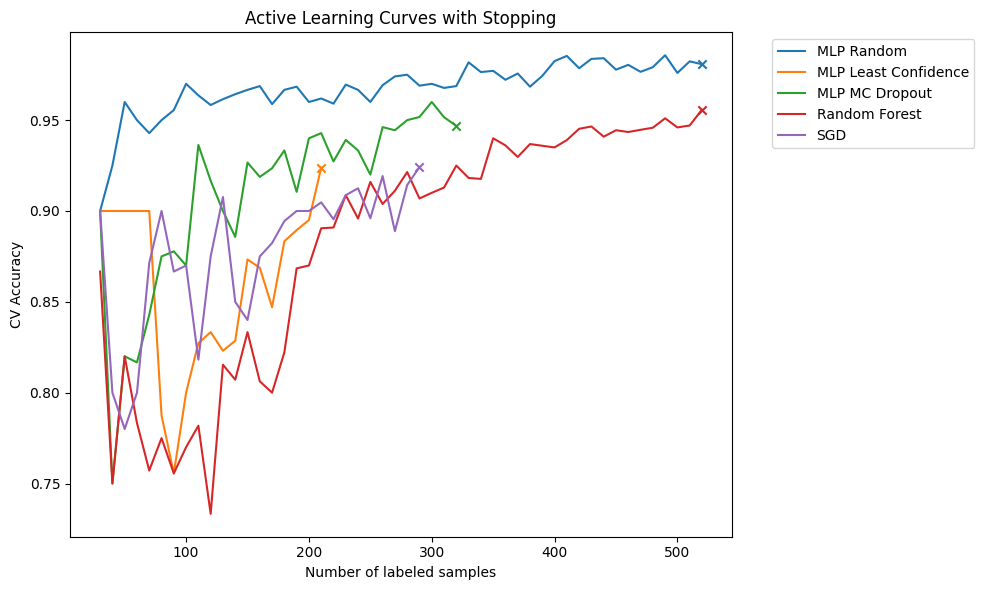

In [60]:
# ------------------------
# Run and plot
# ------------------------
strategies = [
    ('random',     False, False, False),
    ('least_conf', False, False, False),
    ('mc_dropout', True,  False, False),
    ('least_conf', False, True,  False),
    ('least_conf', False, False, True ),
]
keys = ['MLP Random','MLP Least Confidence','MLP MC Dropout','Random Forest','SGD']

results = {}
for (strat, mc, rf, sgd), k in zip(strategies, keys):
    results[k] = run_active_learning(strat, use_mc=mc, use_rf=rf, use_sgd=sgd)

# flatten per-strategy (average seeds)
flat = {k: {f: v for f, v in run.items()} for k, run in results.items() for run in [run_active_learning(strat, use_mc=mc, use_rf=rf, use_sgd=sgd)]}

# just plot one seed per strategy for illustration
plot_active_learning({k: list(v.values())[0] for k, v in results.items()})

In [67]:
def plot_active_learning(histories):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10, 6))

    for name, hist in histories.items():
        x_vals = np.array(hist['n_labeled'])
        y_vals = np.array(hist['cv_acc'])

        # Select points in steps of 10 or final
        batch_x = []
        batch_y = []
        for i in range(len(x_vals)):
            if x_vals[i] % 10 == 0 or i == len(x_vals) - 1:
                batch_x.append(x_vals[i])
                batch_y.append(y_vals[i])

        # Convert labeled sample count to batch index (starts at batch 0)
        batch_numbers = list(range(len(batch_x)))

        plt.plot(batch_numbers, batch_y, label=name)
        plt.scatter(batch_numbers[-1], batch_y[-1], marker='x')

    plt.xlabel('Iterations (batches of 10)')
    plt.ylabel('Accuracy')
    plt.title('Active Learning Curves by Batch')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

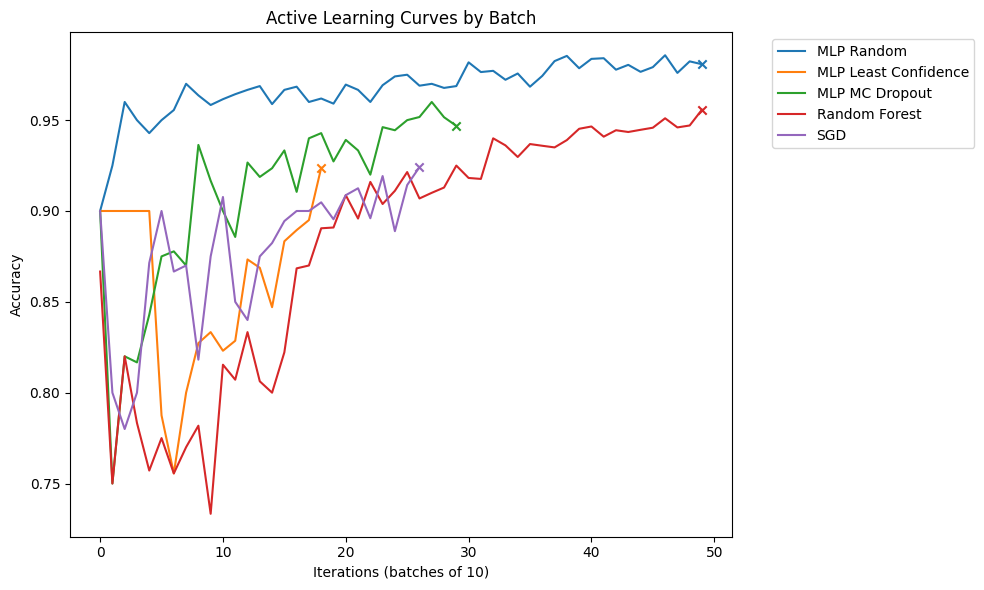

In [68]:
# just plot one seed per strategy for illustration
plot_active_learning({k: list(v.values())[0] for k, v in results.items()})